Maryam Tariq (22-BSAI-66)


2. Health Risk Classification

Design a model that predicts the likelihood of a patient having a medical condition (e.g.,
diabetes or heart disease) based on health indicators.

Dataset: Pima Indians Diabetes Database

Integration:
*   Perform data preprocessing (handle missing values, normalize numeric data).
*   Apply SVM and Decision Tree for classification.
*   Compare both models’ results and discuss overfitting and accuracy trade-offs

importing Libraries

In [27]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, classification_report
)
import matplotlib.pyplot as plt

Load Dataset

In [28]:
df = pd.read_csv("/content/diabetes.csv")

In [29]:
print("Shape: ", df.shape)
df.head()

Shape:  (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Replace Zeros with NaN (missing columns)

In [32]:
cols_with_zero = ['Glucose', "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [33]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

Split into X and y

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Handling misiing values (Median filling)

In [35]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

Noramlization

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model 1 - Support Vector Machine

In [39]:
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [47]:
print("SVM Result: ")
print("Accuracy: %.2f" % accuracy_score(y_test, svm_pred))
print("Classification Report: ", classification_report(y_test, svm_pred))

SVM Result: 
Accuracy: 0.75
Classification Report:                precision    recall  f1-score   support

           0       0.78      0.84      0.81        99
           1       0.67      0.58      0.62        55

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



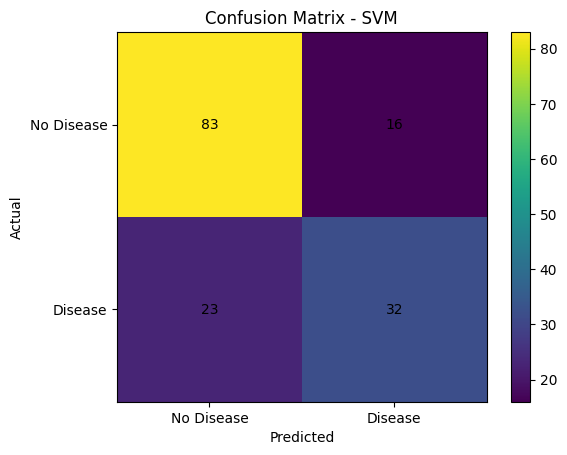

In [54]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.imshow(cm_svm, interpolation='nearest')
plt.title('Confusion Matrix - SVM')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])

for i in range(cm_svm.shape[0]):
    for j in range(cm_svm.shape[1]):
        plt.text(j, i, cm_svm[i, j], ha='center', va='center')

plt.show()

SVM gives more stable accuracy and generalizes better

Model 2 - Decision Tree Classifier

In [50]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [51]:
print("Decision Tree Classifier Result: ")
print("Accuracy: %.2f" % accuracy_score(y_test, dt_pred))
print("Classification Report: ", classification_report(y_test, dt_pred))

Decision Tree Classifier Result: 
Accuracy: 0.71
Classification Report:                precision    recall  f1-score   support

           0       0.84      0.68      0.75        99
           1       0.57      0.76      0.65        55

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.71       154



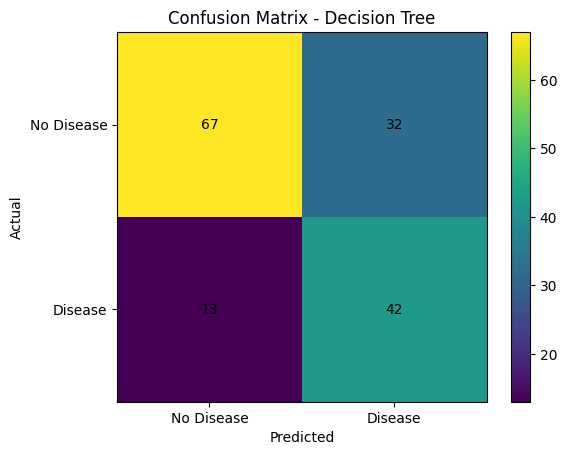

In [55]:
cm_dt = confusion_matrix(y_test, dt_pred)

plt.imshow(cm_dt, interpolation='nearest')
plt.title('Confusion Matrix - Decision Tree')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.yticks([0, 1], ['No Disease', 'Disease'])

for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        plt.text(j, i, cm_dt[i, j], ha='center', va='center')

plt.show()

Decision Tree is more likely to overfit when depth is large. It is controlled this using max_depth=4.

ROC Curve

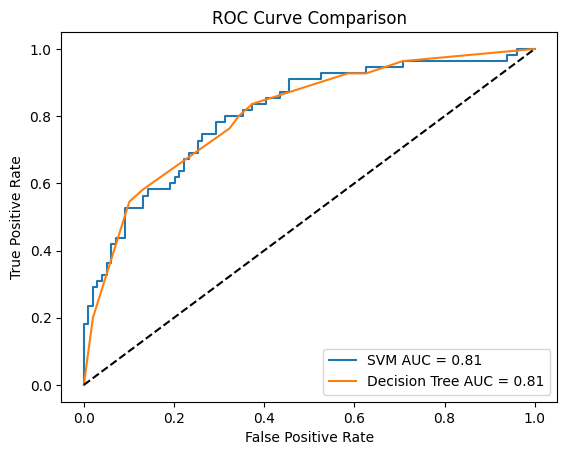

In [52]:
svm_prob = svm.predict_proba(X_test)[:, 1]
dt_prob = dt.predict_proba(X_test)[:, 1]

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

plt.figure()
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {auc(fpr_svm, tpr_svm):.2f}")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree AUC = {auc(fpr_dt, tpr_dt):.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The SVM model achieved higher accuracy than the Decision Tree model.
Decision Tree is simple and interpretable but may overfit if not properly tuned.
SVM handles complex relationships but is slower.”